# Trabajo Práctico 1 - Grupo 02

### Ejercicio 2

Integrantes:
- Bermudez, Agustin
- Calderón, Tiago
- Gonzalez Pautaso, Mateo
- Moreyra, Santiago
- Nieves, Maylen

## 1. Análisis exploratorio y preprocesamiento

### Carga de datos
Para el desarrollo de este ejercicio se utilizan datos de observaciones meteorológicas diarias provenientes de numerosas estaciones ubicadas a lo largo de Australia, con el objetivo de predecir si lloverá al día siguiente (`RainTomorrow`) a partir de las condiciones climáticas registradas en el día actual.

#### Sobre el dataset
Los datos corresponden a observaciones meteorológicas diarias registradas en distintas estaciones de Australia durante aproximadamente 10 años, obtenidos desde [Kaggle](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package?resource=download).

El archivo está en formato `.csv` y se carga usando el método específico para ello de `pandas`.

Para este ejercicio se filtran únicamente las estaciones pertenecientes a los territorios asignados: **Queensland**, **Nueva Gales del Sur** y **Territorio de la Capital Australiana (ACT)**.

Cada fila representa las observaciones de un día en una estación meteorológica particular e incluye variables como temperatura, humedad, presión atmosférica, dirección y velocidad del viento, entre otras. La variable objetivo es `RainTomorrow`, que indica si llovió al día siguiente (`Yes`/`No`).

Descripción de variables

Variables cuantitativas (numéricas continuas)
- **MinTemp:** Temperatura mínima del día (°C)
- **MaxTemp:** Temperatura máxima del día (°C)
- **Rainfall:** Cantidad de lluvia registrada en el día (mm)
- **Evaporation:** Evaporación registrada en las 24 horas hasta las 9am (mm)
- **Sunshine:** Horas de sol brillante en el día
- **WindGustSpeed:** Velocidad de la ráfaga de viento más fuerte en las 24 horas hasta medianoche (km/h)
- **WindSpeed9am:** Velocidad del viento promediada en los 10 minutos previos a las 9am (km/h)
- **WindSpeed3pm:** Velocidad del viento promediada en los 10 minutos previos a las 3pm (km/h)
- **Humidity9am:** Humedad relativa a las 9am (%)
- **Humidity3pm:** Humedad relativa a las 3pm (%)
- **Pressure9am:** Presión atmosférica reducida al nivel del mar a las 9am (hPa)
- **Pressure3pm:** Presión atmosférica reducida al nivel del mar a las 3pm (hPa)
- **Cloud9am:** Fracción del cielo cubierta por nubes a las 9am, medida en oktas (0-8)
- **Cloud3pm:** Fracción del cielo cubierta por nubes a las 3pm, medida en oktas (0-8)
- **Temp9am:** Temperatura a las 9am (°C)
- **Temp3pm:** Temperatura a las 3pm (°C)

Variables cualitativas (categóricas)
- **Date:** Fecha de la observación
- **Location:** Nombre de la estación meteorológica
- **WindGustDir:** Dirección de la ráfaga de viento más fuerte (16 puntos cardinales)
- **WindDir9am:** Dirección del viento a las 9am (16 puntos cardinales)
- **WindDir3pm:** Dirección del viento a las 3pm (16 puntos cardinales)
- **RainToday:** Variable binaria: 1 si la precipitación supera 1mm, 0 en caso contrario
- **RainTomorrow:** Variable objetivo binaria: indica si llovió al día siguiente (Yes/No)

In [ ]:
import pandas as pd
import numpy as np

#Visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('weatherAUS.csv')

territorios = ['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree', 'Newcastle',
               'NorahHead', 'Penrith', 'Richmond', 'Sydney', 'SydneyAirport',
               'WaggaWagga', 'Williamtown', 'Wollongong',  # Nueva Gales del Sur
               'Canberra', 'Tuggeranong', 'MountGinini',   # Territorio de la Capital
               'Brisbane', 'Cairns', 'GoldCoast', 'Townsville']  # Queensland

df = df[df['Location'].isin(territorios)].reset_index(drop=True)

In [ ]:
# Ver las primeras filas
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.40,22.90,0.60,NaN,NaN,W,44.00,W,...,71.00,22.00,1007.70,1007.10,8.00,NaN,16.90,21.80,No,No
1,2008-12-02,Albury,7.40,25.10,0.00,NaN,NaN,WNW,44.00,NNW,...,44.00,25.00,1010.60,1007.80,NaN,NaN,17.20,24.30,No,No
2,2008-12-03,Albury,12.90,25.70,0.00,NaN,NaN,WSW,46.00,W,...,38.00,30.00,1007.60,1008.70,NaN,2.00,21.00,23.20,No,No
3,2008-12-04,Albury,9.20,28.00,0.00,NaN,NaN,NE,24.00,SE,...,45.00,16.00,1017.60,1012.80,NaN,NaN,18.10,26.50,No,No
4,2008-12-05,Albury,17.50,32.30,1.00,NaN,NaN,W,41.00,ENE,...,82.00,33.00,1010.80,1006.00,7.00,8.00,17.80,29.70,No,No


### Estudio inicial del dataframe

In [ ]:
print(df.dtypes)
print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

Dimensiones: 64406 filas x 23 columnas


El dataset filtrado contiene observaciones meteorológicas diarias de 21 estaciones distribuidas en Queensland, Nueva Gales del Sur y el Territorio de la Capital. Cada fila representa un día en una estación particular.
Las variables se pueden clasificar en:

- **Numéricas continuas:** temperaturas, lluvia, evaporación, horas de sol, velocidad del viento, humedad, presión atmosférica, nubosidad.
- **Categóricas:** dirección del viento (`WindGustDir`, `WindDir9am`, `WindDir3pm`), lluvia hoy (`RainToday`) y lluvia mañana (`RainTomorrow`, variable objetivo).
- **Fecha:** `Date`, actualmente en formato object.

In [ ]:
# Convertir Date a datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ver rango temporal
print(f"Período: {df['Date'].min()} → {df['Date'].max()}")
print(f"Estaciones disponibles:\n{df['Location'].value_counts()}")

Período: 2007-11-01 00:00:00 → 2017-06-25 00:00:00
Estaciones disponibles:
Location
Canberra         3436
Sydney           3344
Brisbane         3193
Townsville       3040
Albury           3040
Wollongong       3040
MountGinini      3040
Cairns           3040
GoldCoast        3040
Newcastle        3039
Penrith          3039
Tuggeranong      3039
BadgerysCreek    3009
Moree            3009
CoffsHarbour     3009
Cobar            3009
Richmond         3009
SydneyAirport    3009
Williamtown      3009
WaggaWagga       3009
NorahHead        3004
Name: count, dtype: int64


### Análisis de valores faltantes

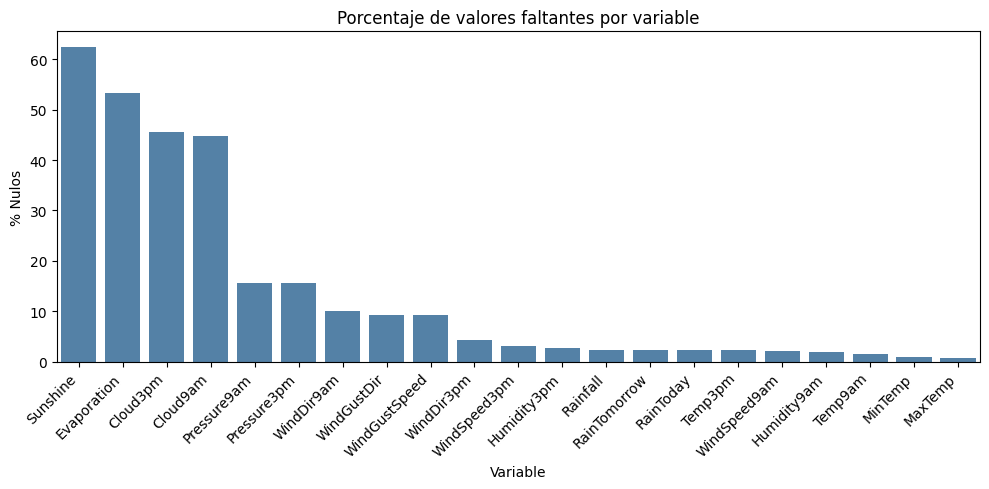

In [ ]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% Nulos': pct_nulos
}).query('Nulos > 0').sort_values('% Nulos', ascending=False)

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(x=resumen_nulos.index, y=resumen_nulos['% Nulos'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Porcentaje de valores faltantes por variable')
plt.ylabel('% Nulos')
plt.xlabel('Variable')
plt.tight_layout()
plt.show()

A partir del gráfico se identifican tres grupos de variables según su porcentaje de nulos:

- `Sunshine` (62.43%) y `Evaporation` (53.32%) superan el 50% de valores faltantes. Imputar más de la mitad de los datos de una variable introduciría más ruido que información real. Además, estas mediciones no son registradas de forma estándar por todas las estaciones meteorológicas, lo que explica estructuralmente su ausencia. Se decide eliminarlas.
- `Cloud9am` (44.78%) y `Cloud3pm` (45.67%) tienen una proporción alta pero por debajo del umbral. Se imputan con la mediana por estación.
- El resto de las variables numéricas presentan menos del 16% de nulos y se imputan también con la mediana por estación (`Location`), ya que el clima varía significativamente entre regiones y usar una mediana global introduciría sesgo.
- `RainToday` y `RainTomorrow` (2.38%) se tratan por separado: al ser la variable objetivo y su análogo del día actual, no es válido imputarlas, por lo que se eliminan las filas con valores nulos en estas columnas.

In [ ]:
# Eliminar columnas con más del 50% de nulos
cols_eliminar = pct_nulos[pct_nulos > 50].index.tolist()
print(f"Columnas eliminadas: {cols_eliminar}")
df = df.drop(columns=cols_eliminar)

# Imputar numéricas con mediana por Location
cols_numericas = df.select_dtypes(include='float64').columns
for col in cols_numericas:
    df[col] = df.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    )
print(f"Nulos restantes en numéricas: {df[cols_numericas].isnull().sum().sum()}")

# Eliminar filas con nulos en el target y RainToday
df = df.dropna(subset=['RainToday', 'RainTomorrow']).reset_index(drop=True)
print(f"Filas tras limpieza del target: {df.shape[0]}")

Columnas eliminadas: ['Evaporation', 'Sunshine']
Nulos restantes en numéricas: 57617
Filas tras limpieza del target: 62046


El resultado de 57,617 nulos restantes resulta inesperado dado que se aplicó imputación por mediana. Para diagnosticar la causa, se investiga si alguna combinación estación-columna tiene todos sus valores en NaN, lo que explicaría por qué la mediana local no pudo imputar nada en esos casos.

In [ ]:
# Ver qué combinaciones Location-columna quedaron todas en NaN
cols_numericas = df.select_dtypes(include='float64').columns

problemas = []
for col in cols_numericas:
    for loc in df['Location'].unique():
        subset = df[df['Location'] == loc][col]
        if subset.isnull().all():
            problemas.append({'Location': loc, 'Columna': col, 'Nulos': subset.isnull().sum()})

pd.DataFrame(problemas).sort_values('Columna')

,Location,Columna,Nulos
18,GoldCoast,Cloud3pm,2924
16,Tuggeranong,Cloud3pm,2959
15,Penrith,Cloud3pm,2911
14,NorahHead,Cloud3pm,2888
13,BadgerysCreek,Cloud3pm,2877
17,MountGinini,Cloud3pm,2816
12,GoldCoast,Cloud9am,2924
11,MountGinini,Cloud9am,2816
10,Tuggeranong,Cloud9am,2959
9,Penrith,Cloud9am,2911


Al verificar los nulos restantes, se detecta que ciertas estaciones tienen columnas completamente vacías: `Cloud9am` y `Cloud3pm` en GoldCoast, Tuggeranong, Penrith, NorahHead, BadgerysCreek y MountGinini; `Pressure9am` y `Pressure3pm` en Newcastle, Penrith y MountGinini; y WindGustSpeed en Newcastle. En estos casos la mediana por estación también es NaN, por lo que la imputación anterior no tuvo efecto. Para resolverlo se aplica un segundo paso de imputación usando la mediana global como fallback.

In [ ]:
# Fallback: imputar con mediana global los nulos que quedaron
cols_numericas = df.select_dtypes(include='float64').columns

for col in cols_numericas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"Nulos restantes tras fallback: {df[cols_numericas].isnull().sum().sum()}")

Nulos restantes tras fallback: 0


Las variables de dirección del viento (`WindGustDir`, `WindDir9am`, `WindDir3pm`) son categóricas nominales con 16 valores posibles correspondientes a los puntos cardinales. Se imputan con la moda por estación (`Location`), ya que la dirección predominante del viento varía según la geografía de cada región.

In [ ]:
cols_viento = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in cols_viento:
    df[col] = df.groupby('Location')[col].transform(
        lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
    )

print("Nulos restantes en variables de viento:")
print(df[cols_viento].isnull().sum())

Nulos restantes en variables de viento:
WindGustDir    2929
WindDir9am        0
WindDir3pm        0
dtype: int64


Se detecta que Newcastle no tiene ningún registro válido de `WindGustDir`, por lo que la moda local también es NaN. Se aplica un fallback con la moda global.

In [ ]:
# Fallback: moda global para WindGustDir
df['WindGustDir'] = df['WindGustDir'].fillna(df['WindGustDir'].mode()[0])

print("Nulos restantes en variables de viento:")
print(df[cols_viento].isnull().sum())

Nulos restantes en variables de viento:
WindGustDir    0
WindDir9am     0
WindDir3pm     0
dtype: int64


### Análisis de valores atípicos

Se analizan los rangos de las variables numéricas clave para detectar valores físicamente imposibles.

In [ ]:
cols_check = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
              'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm']

df[cols_check].describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm
count,62046.00,62046.00,62046.00,62046.00,62046.00,62046.00,62046.00,62046.00
mean,13.05,23.76,2.90,38.48,69.68,53.34,1017.96,1015.25
std,6.76,6.68,10.51,13.08,17.18,19.81,6.11,6.07
min,-8.50,-4.80,0.00,7.00,3.00,1.00,986.70,982.90
25%,8.40,19.30,0.00,30.00,58.00,39.00,1014.40,1011.60
50%,13.60,24.00,0.00,37.00,70.00,54.00,1018.00,1015.30
75%,18.40,28.40,0.60,44.00,82.00,66.00,1021.40,1018.70
max,29.70,47.30,371.00,135.00,100.00,100.00,1040.60,1037.90


Los rangos observados son físicamente plausibles para el contexto geográfico del dataset. La lluvia máxima de 371mm y ráfagas de hasta 135 km/h son valores extremos pero posibles en zonas tropicales como Queensland. Las temperaturas, humedad y presión se encuentran dentro de rangos válidos. No se eliminan registros por valores atípicos ya que, además, los modelos de árbol de decisión y random forest son inherentemente robustos frente a outliers al trabajar con particiones binarias en lugar de distancias.

### Análisis de la variable objetivo

#### Distribución de la variable objetivo

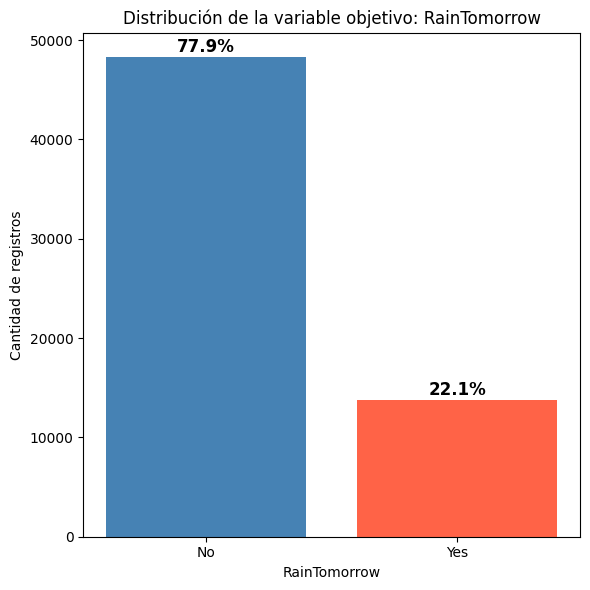

No llueve: 48312 (77.9%)
Llueve:    13734 (22.1%)


In [ ]:
target_counts = df['RainTomorrow'].value_counts()
target_pct = df['RainTomorrow'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
bars = plt.bar(target_counts.index, target_counts.values, color=['steelblue', 'tomato'])
for bar, pct in zip(bars, target_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Distribución de la variable objetivo: RainTomorrow')
plt.ylabel('Cantidad de registros')
plt.xlabel('RainTomorrow')
plt.tight_layout()
plt.show()

print(f"No llueve: {target_counts['No']} ({target_pct['No']:.1f}%)")
print(f"Llueve:    {target_counts['Yes']} ({target_pct['Yes']:.1f}%)")

El dataset está claramente desbalanceado: aproximadamente el 78% de los días no llueve y solo el 22% sí llueve. Este desbalance debe tenerse en cuenta al entrenar los modelos (uso de `class_weight='balanced'` y `scale_pos_weight`) y al elegir la métrica de evaluación (se prioriza recall sobre accuracy).

#### Matriz de correlacion entre variables continuas

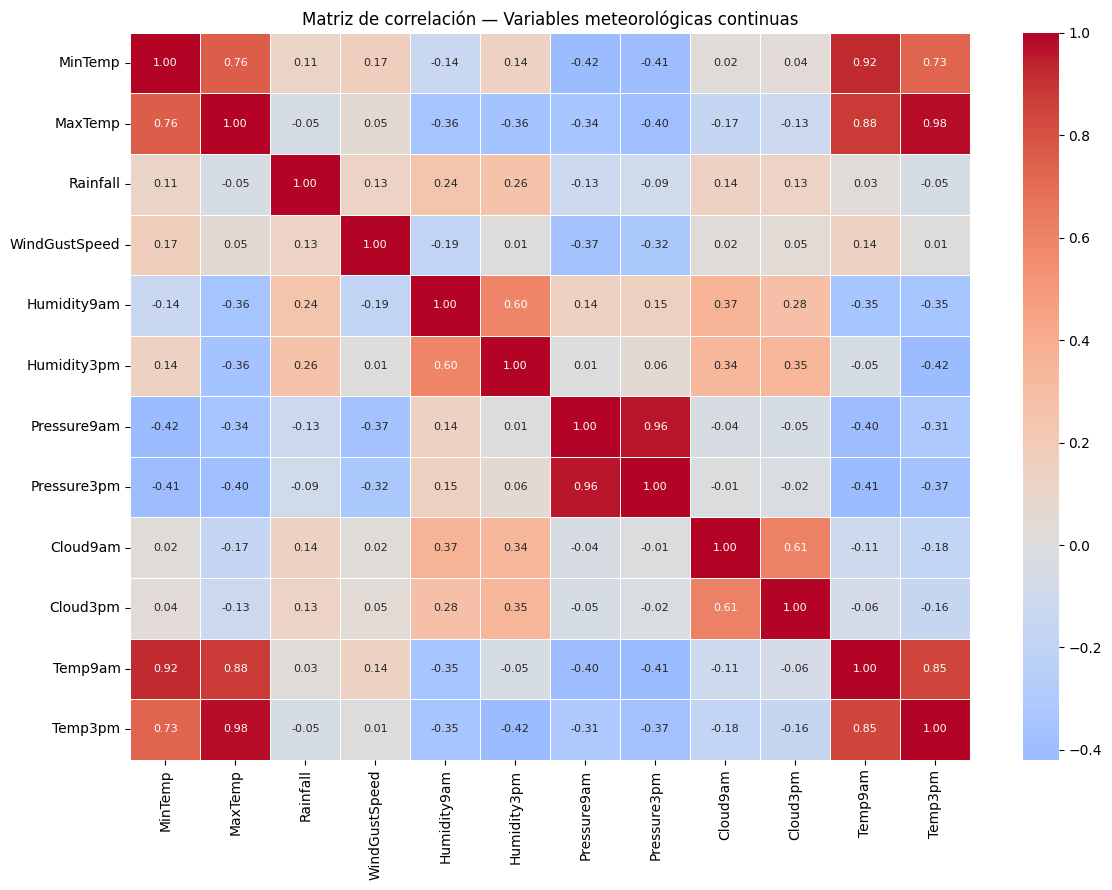

In [ ]:
cols_corr = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
             'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
             'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Variables meteorológicas continuas')
plt.tight_layout()
plt.show()

#### Boxplots: variables clave según RainTomorrow

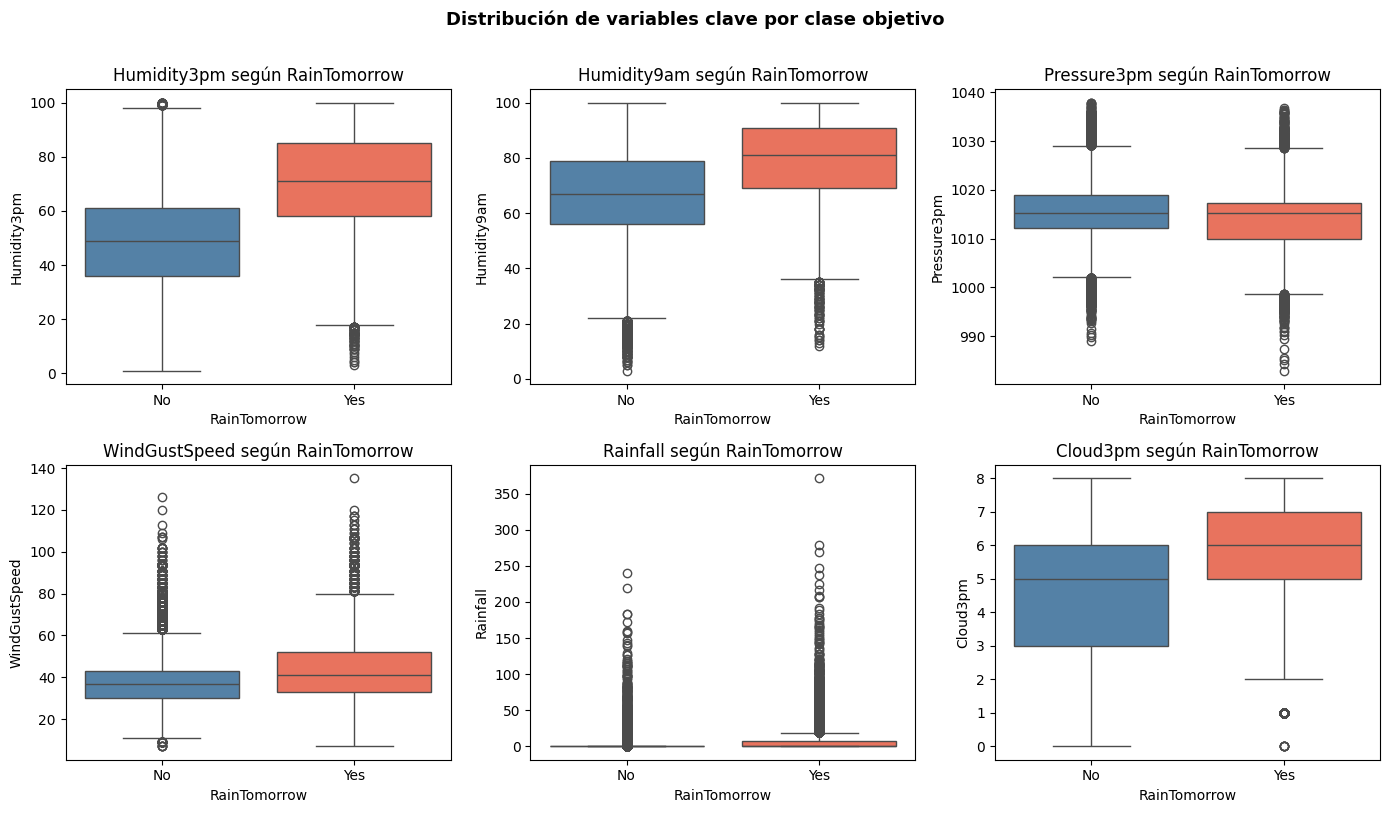

In [ ]:
vars_boxplot = ['Humidity3pm', 'Humidity9am', 'Pressure3pm', 'WindGustSpeed', 'Rainfall', 'Cloud3pm']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(vars_boxplot):
    sns.boxplot(
        x='RainTomorrow',
        y=var,
        data=df,
        ax=axes[i],
        hue='RainTomorrow',
        palette={'No': 'steelblue', 'Yes': 'tomato'},
        legend=False
    )
    axes[i].set_title(f'{var} según RainTomorrow')
    axes[i].set_xlabel('RainTomorrow')
    axes[i].set_ylabel(var)

plt.suptitle('Distribución de variables clave por clase objetivo', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Feature Engineering

Se crean nuevas variables que pueden aportar señal predictiva al modelo.

In [ ]:
# Variables temporales
df['Month'] = df['Date'].dt.month
df['Season'] = df['Month'].map({
    12: 'Verano', 1: 'Verano', 2: 'Verano',
    3: 'Otoño',  4: 'Otoño',  5: 'Otoño',
    6: 'Invierno', 7: 'Invierno', 8: 'Invierno',
    9: 'Primavera', 10: 'Primavera', 11: 'Primavera'
})

# Rango térmico diario
df['TempRange'] = df['MaxTemp'] - df['MinTemp']

# Caída de humedad entre mañana y tarde
df['HumidityDrop'] = df['Humidity9am'] - df['Humidity3pm']

# Caída de presión entre mañana y tarde (presión cayendo = posible lluvia)
df['PressureDrop'] = df['Pressure9am'] - df['Pressure3pm']

df[['TempRange', 'HumidityDrop', 'PressureDrop', 'Month', 'Season']].describe()

,TempRange,HumidityDrop,PressureDrop,Month
count,62046.00,62046.00,62046.00,62046.00
mean,10.70,16.34,2.71,6.40
std,4.66,16.75,1.62,3.43
min,-3.00,-67.00,-17.20,1.00
25%,7.20,5.00,2.00,3.00
50%,10.10,15.00,2.70,6.00
75%,13.90,28.00,3.60,9.00
max,32.00,83.00,17.60,12.00


### Encoding y preparación para los modelos

In [ ]:
# Encoding binario de RainToday y RainTomorrow
df['RainToday_enc'] = (df['RainToday'] == 'Yes').astype(int)
df['RainTomorrow_enc'] = (df['RainTomorrow'] == 'Yes').astype(int)

# Label Encoding para direcciones de viento y variables categóricas
le = LabelEncoder()
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location', 'Season']:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Definir features y target
features = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
            'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
            'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
            'Temp9am', 'Temp3pm', 'TempRange', 'HumidityDrop', 'PressureDrop',
            'RainToday_enc', 'WindGustDir_enc', 'WindDir9am_enc', 'WindDir3pm_enc',
            'Location_enc', 'Season_enc', 'Month']

X = df[features]
y = df['RainTomorrow_enc']

print(f"\nShape X: {X.shape}")
print(f"\nDistribución target:")
print(y.value_counts())
print(f"\nDesbalance: {y.value_counts(normalize=True).round(3) * 100}")


Shape X: (62046, 24)

Distribución target:
RainTomorrow_enc
0    48312
1    13734
Name: count, dtype: int64

Desbalance: RainTomorrow_enc
0   77.90
1   22.10
Name: proportion, dtype: float64


### Normalización de variables

 Si bien los modelos de Árbol de decisión y Random Forest son invariantes a la escala de las variables, se realiza una estandarización (StandardScaler) sobre las variables numéricas continuas como paso de preprocesamiento general. Esto se debe a que el Modelo 3 a elección puede requerir que las features estén en una escala comparable. Las variables categóricas codificadas (direcciones de viento, ubicación, estación) y las binarias (RainToday_enc) no se escalan ya que su codificación numérica no representa magnitud.

## 2. Entrenamiento y predicción (80% train / 20% test)

In [ ]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalización DESPUÉS del split para evitar data leakage
scaler = StandardScaler()

cols_escalar = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
                'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
                'Temp9am', 'Temp3pm', 'TempRange', 'HumidityDrop', 'PressureDrop']

scaler.fit(X_train[cols_escalar])

X_train_scaled = X_train.copy()
X_train_scaled[cols_escalar] = scaler.transform(X_train[cols_escalar])

X_test_scaled = X_test.copy()
X_test_scaled[cols_escalar] = scaler.transform(X_test[cols_escalar])

# Nota: los modelos de árbol (Árbol de decisión, Random Forest, XGBoost) son invariantes
# al escalado, por lo que se entrenan con X_train sin escalar. El scaler se guarda en el
# pkl por consistencia, en caso de que se incorpore un modelo lineal futuro.

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train dist: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Scaler ajustado sobre {len(cols_escalar)} columnas")

X_train: (49636, 24) | X_test: (12410, 24)
y_train dist: {0: 0.779, 1: 0.221}
Scaler ajustado sobre 17 columnas


### Modelo 1 – Árbol de decisión

In [ ]:
# Modelo inicial
tree_model = tree.DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=10)
model = tree_model.fit(X=X_train, y=y_train)

# Predicción
y_pred = model.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8371474617244158
Recall: 0.47906807426283216
Precision: 0.6904512067156349
F1 score: 0.5656565656565656
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      9663
           1       0.69      0.48      0.57      2747

    accuracy                           0.84     12410
   macro avg       0.78      0.71      0.73     12410
weighted avg       0.83      0.84      0.83     12410



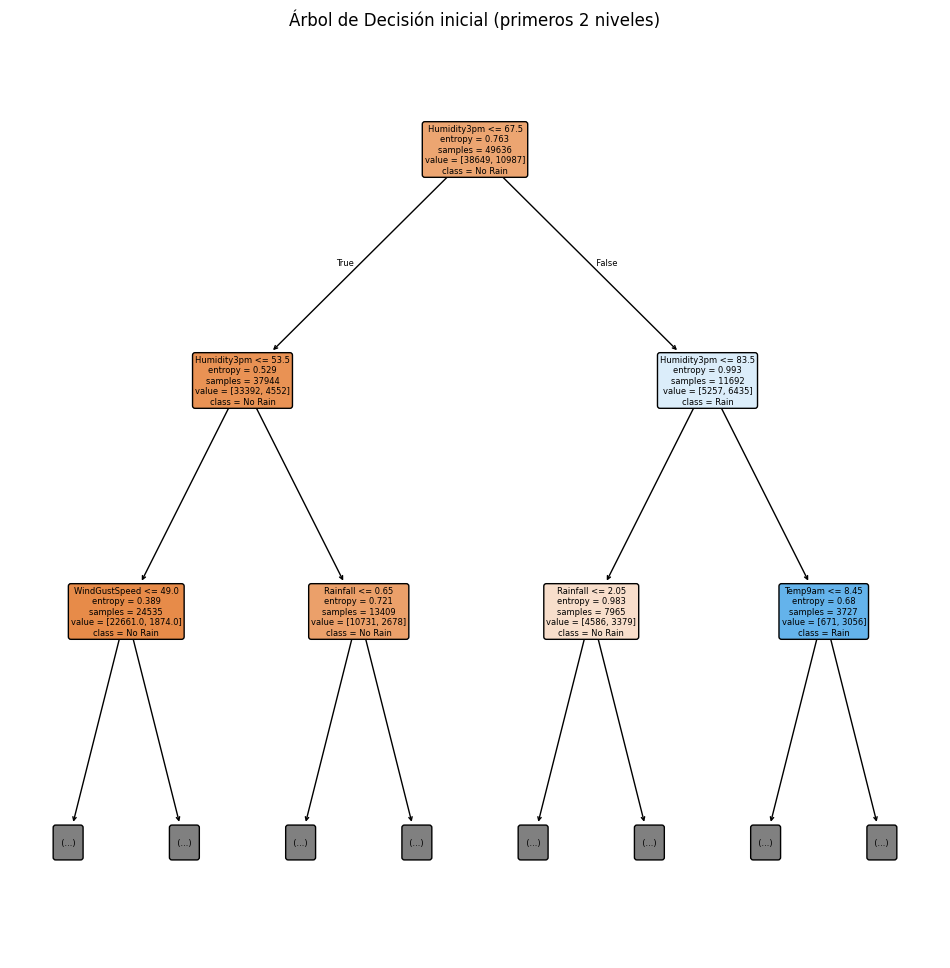

In [ ]:
# Gráfico árbol reducido (legible)
plt.figure(figsize=(12, 12))
tree.plot_tree(model, max_depth=2, feature_names=X.columns.tolist(), filled=True, rounded=True, class_names=['No Rain', 'Rain'])
plt.title('Árbol de Decisión inicial (primeros 2 niveles)')
plt.show()

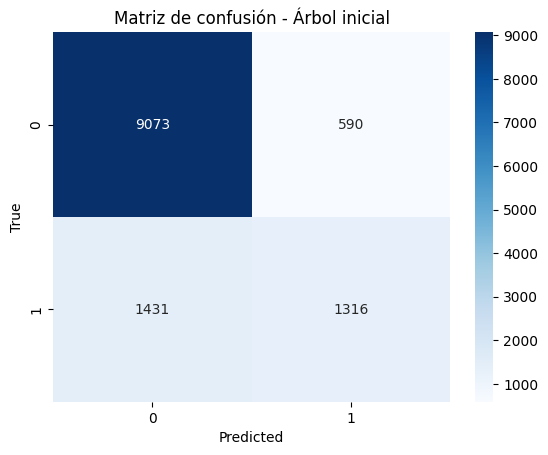

In [ ]:
# Matriz de confusión
tabla = confusion_matrix(y_test, y_pred)
sns.heatmap(tabla, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de confusión - Árbol inicial')
plt.show()

In [ ]:
# Importancia de atributos
importancias = sorted(zip(X.columns.tolist(), model.feature_importances_), key=lambda x: x[1], reverse=True)

df_importancias = pd.DataFrame(importancias, columns=['Variable', 'Importancia'])
df_importancias['Importancia'] = df_importancias['Importancia'].map('{:.4f}'.format)
print(df_importancias.to_string(index=False))

       Variable Importancia
    Humidity3pm      0.5509
  WindGustSpeed      0.0603
       Rainfall      0.0560
        Temp9am      0.0297
       Cloud3pm      0.0282
    Pressure3pm      0.0267
   PressureDrop      0.0265
   Location_enc      0.0253
    Humidity9am      0.0243
      TempRange      0.0206
   HumidityDrop      0.0181
        Temp3pm      0.0170
    Pressure9am      0.0167
 WindDir3pm_enc      0.0165
        MinTemp      0.0163
        MaxTemp      0.0143
WindGustDir_enc      0.0121
          Month      0.0105
   WindSpeed3pm      0.0099
 WindDir9am_enc      0.0076
   WindSpeed9am      0.0070
     Season_enc      0.0033
       Cloud9am      0.0023
  RainToday_enc      0.0000


In [ ]:
# Modelo con poda
tree_poda = tree.DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=10, ccp_alpha=0.001)
model_poda = tree_poda.fit(X=X_train, y=y_train)
y_pred_poda = model_poda.predict(X_test)

print("Accuracy poda:", accuracy_score(y_test, y_pred_poda))
print("Recall poda:", recall_score(y_test, y_pred_poda))
print("Precision poda:", precision_score(y_test, y_pred_poda))
print("F1 score poda:", f1_score(y_test, y_pred_poda))

Accuracy poda: 0.8323126510878324
Recall poda: 0.421914816163087
Precision poda: 0.7015738498789347
F1 score poda: 0.5269379404410093


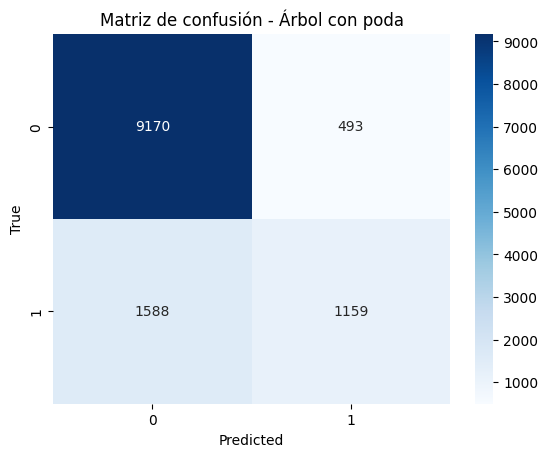

In [ ]:
tabla_poda = confusion_matrix(y_test, y_pred_poda)
sns.heatmap(tabla_poda, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de confusión - Árbol con poda')
plt.show()

#### Optimización de hiperparámetros


In [ ]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01]
}

grid_search = GridSearchCV(
    tree.DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor F1 en CV:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores hiperparámetros: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 20}
Mejor F1 en CV: 0.5904631816198991


In [ ]:
# Modelo final con hiperparámetros optimizados
model_final = grid_search.best_estimator_

# Predicción
y_pred_final = model_final.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("F1 score:", f1_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Accuracy: 0.7697824335213538
Recall: 0.7127775755369494
Precision: 0.48633879781420764
F1 score: 0.5781780599438949
              precision    recall  f1-score   support

           0       0.91      0.79      0.84      9663
           1       0.49      0.71      0.58      2747

    accuracy                           0.77     12410
   macro avg       0.70      0.75      0.71     12410
weighted avg       0.81      0.77      0.78     12410



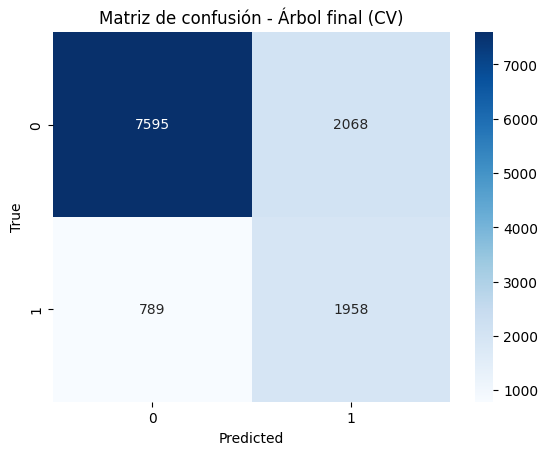

In [ ]:
# Matriz de confusión con hiperparámetros optimizados
tabla_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(tabla_final, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de confusión - Árbol final (CV)')
plt.show()

In [ ]:
# Evaluación en el conjunto de entrenamiento (para detectar overfitting)
y_train_pred_dt = model_final.predict(X_train)
print("=== Árbol de decisión — Performance en TRAIN ===")
print("Train — Accuracy: ", accuracy_score(y_train, y_train_pred_dt))
print("Train — Recall:   ", recall_score(y_train, y_train_pred_dt))
print("Train — Precision:", precision_score(y_train, y_train_pred_dt))
print("Train — F1:       ", f1_score(y_train, y_train_pred_dt))

=== Árbol de decisión — Performance en TRAIN ===
Train — Accuracy:  0.8001249093399951
Train — Recall:    0.8042231728406298
Train — Precision: 0.5320968324701915
Train — F1:        0.6404522886239263


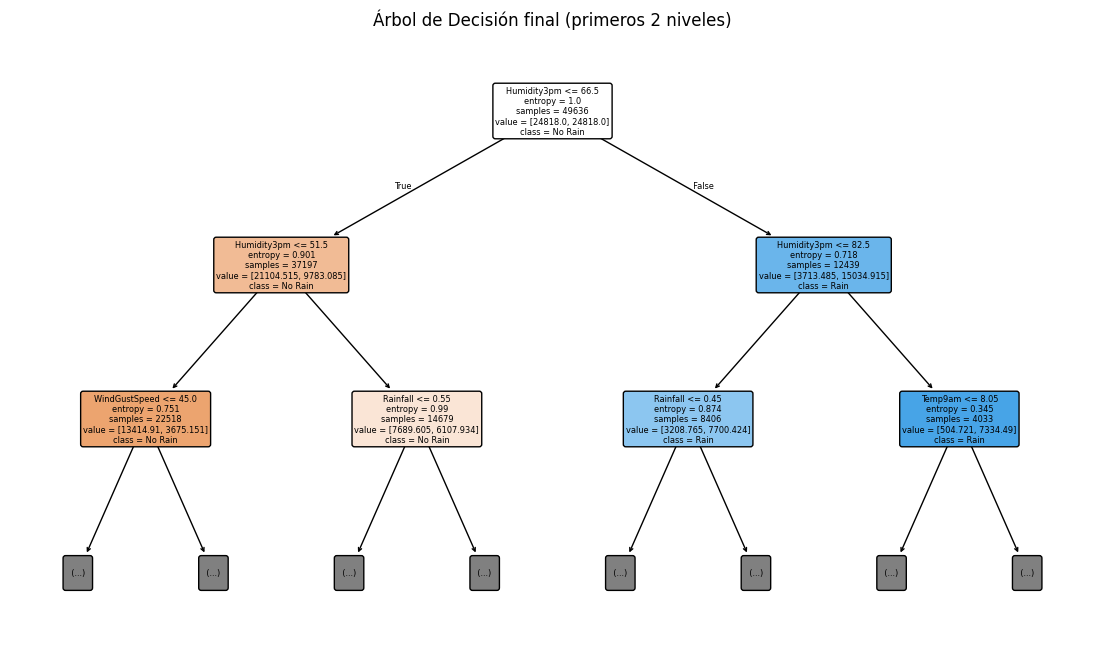

In [ ]:
# Gráfico árbol reducido (legible)
plt.figure(figsize=(14, 8))
tree.plot_tree(model_final, max_depth=2, feature_names=X.columns.tolist(), filled=True, rounded=True, class_names=['No Rain', 'Rain'])
plt.title('Árbol de Decisión final (primeros 2 niveles)')
plt.show()

#### Importancia de atributos


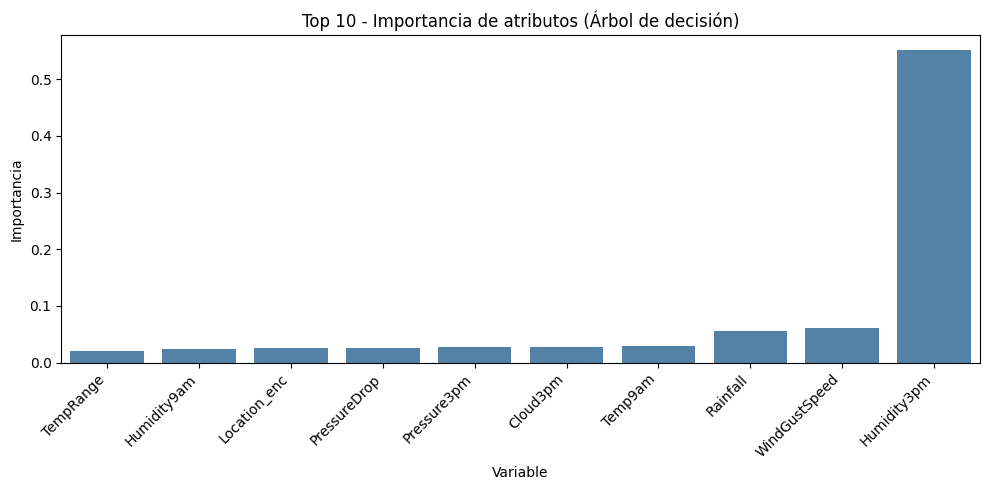

In [ ]:
df_plot = df_importancias.head(10).copy()
df_plot['Importancia'] = df_plot['Importancia'].astype(float)
df_plot = df_plot.sort_values('Importancia', ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='Variable', y='Importancia', data=df_plot, color='steelblue', order=df_plot['Variable'])
plt.title('Top 10 - Importancia de atributos (Árbol de decisión)')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de reglas del árbol
El nodo raíz divide por Humidity3pm <= 66.5. Si la humedad a las 3pm es baja (≤ 66.5%), el árbol va por la rama izquierda (naranja, No llueve), y si es alta (> 66.5%) va por la derecha (azul, Llueve).

Rama izquierda (humedad baja, tiende a No llueve):

Si además Humidity3pm <= 51.5 y WindGustSpeed <= 45 → No llueve con alta confianza

Si Humidity3pm está entre 51.5 y 66.5, se evalúa Rainfall <= 0.55 para refinar

Rama derecha (humedad alta, tiende a Llueve):

Si Humidity3pm <= 82.5 se evalúa Rainfall <= 0.45 para decidir

Si Humidity3pm > 82.5 se evalúa Temp9am <= 8.05, temperaturas bajas con humedad muy alta indican lluvia casi segura

#### Evaluación de performance
El modelo final obtenido mediante GridSearchCV con validación cruzada de 5 folds alcanzó un accuracy de 0.8 y un recall de 0.8 para la clase lluvia. Dado el desbalance de clases presente en el dataset (78% No lluvia / 22% lluvia), se utilizó class_weight='balanced' para que el modelo no ignorara la clase minoritaria durante el entrenamiento. Como métrica principal se priorizó el recall: el modelo detecta correctamente 8 de cada 10 días de lluvia real. La precision de 0.53 indica que hay falsos positivos, pero en contexto meteorológico es preferible alertar de más que no detectar una lluvia real.

### Modelo 2 – Random Forest

In [ ]:
print("Proporción de clases en y_train:")
print(y_train.value_counts(normalize=True))

Proporción de clases en y_train:
RainTomorrow_enc
0   0.78
1   0.22
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo inicial
rf_inicial = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_inicial.fit(X_train, y_train)
y_pred_rf = rf_inicial.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:",   recall_score(y_test, y_pred_rf))
print("Precision:",precision_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8479452054794521
Recall: 0.4273753185293047
Precision: 0.7889784946236559
F1 Score: 0.5544273907910272
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      9663
           1       0.79      0.43      0.55      2747

    accuracy                           0.85     12410
   macro avg       0.82      0.70      0.73     12410
weighted avg       0.84      0.85      0.83     12410



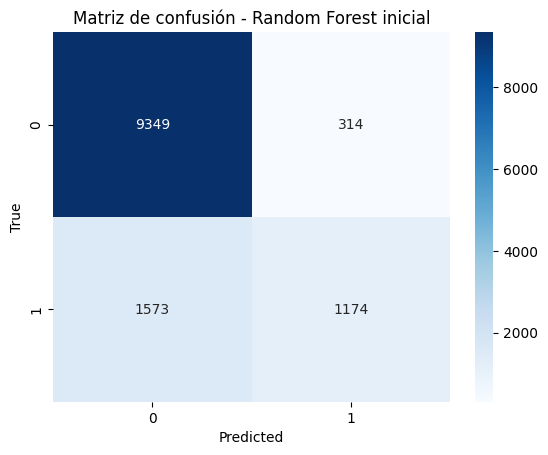

In [ ]:
tabla_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(tabla_rf, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de confusión - Random Forest inicial')
plt.show()

#### Optimización de hiperparámetros

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
from sklearn.ensemble import RandomForestClassifier

params_rf = {
    'n_estimators': [100],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'criterion': ['entropy'],
    'class_weight': ['balanced']
}

kfoldcv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=params_rf,
    scoring=make_scorer(recall_score),
    cv=kfoldcv,
    n_iter=8,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", rf_search.best_params_)
print(f"Mejor Recall (CV): {rf_search.best_score_:.4f}")

Mejores hiperparámetros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced'}
Mejor Recall (CV): 0.6937


In [ ]:
rf_final = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_pred_rf_final = rf_final.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf_final))
print("Recall:", recall_score(y_test, y_pred_rf_final))
print("Precision:", precision_score(y_test, y_pred_rf_final))
print("F1 Score:", f1_score(y_test, y_pred_rf_final))
print(classification_report(y_test, y_pred_rf_final))

# Evaluación en el conjunto de entrenamiento (para detectar overfitting)
y_train_pred_rf = rf_final.predict(X_train)
print("=== Random Forest — Performance en TRAIN ===")
print("Train — Accuracy: ", accuracy_score(y_train, y_train_pred_rf))
print("Train — Recall:   ", recall_score(y_train, y_train_pred_rf))
print("Train — Precision:", precision_score(y_train, y_train_pred_rf))
print("Train — F1:       ", f1_score(y_train, y_train_pred_rf))

Accuracy: 0.8149879129734086
Recall: 0.6858390971969421
Precision: 0.5679831172746458
F1 Score: 0.6213720316622692
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      9663
           1       0.57      0.69      0.62      2747

    accuracy                           0.81     12410
   macro avg       0.74      0.77      0.75     12410
weighted avg       0.83      0.81      0.82     12410

=== Random Forest — Performance en TRAIN ===
Train — Accuracy:  0.8488395519381094
Train — Recall:    0.7831983252935287
Train — Precision: 0.6269124289669241
Train — F1:        0.6963946101242261


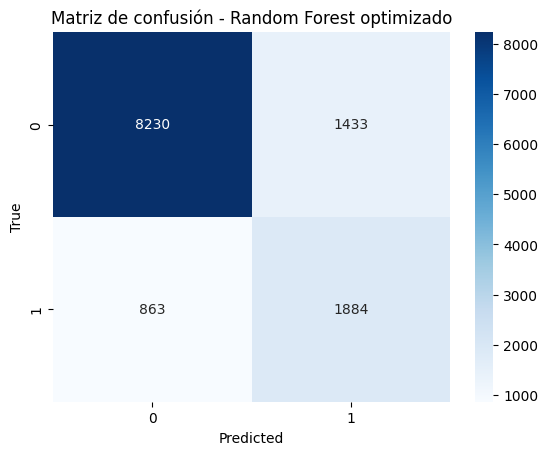

In [ ]:
tabla_rf_final = confusion_matrix(y_test, y_pred_rf_final)
sns.heatmap(tabla_rf_final, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de confusión - Random Forest optimizado')
plt.show()

#### Importancia de atributos

El Random Forest distribuye la importancia entre más variables que el árbol individual, ya que cada árbol del bosque considera subconjuntos aleatorios de features en cada split. Esto reduce el efecto dominante de una única variable y permite identificar señales predictivas más distribuidas.

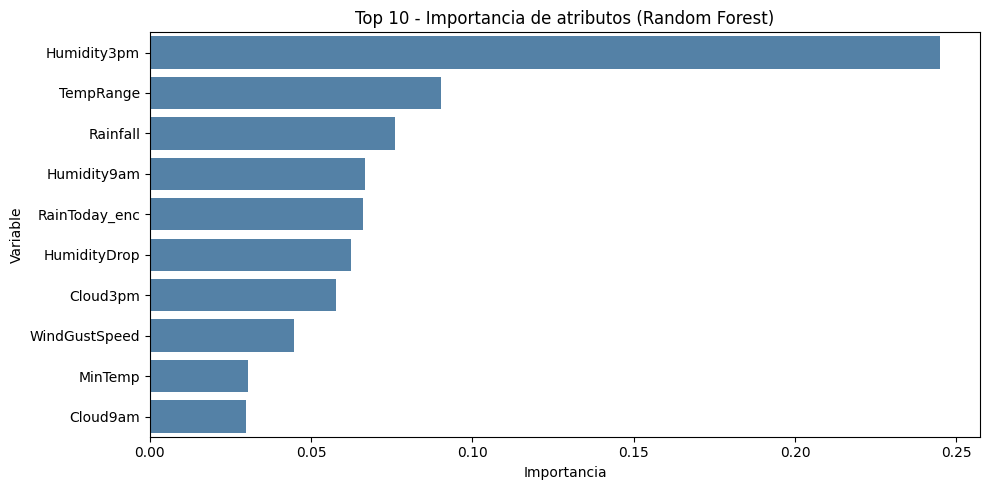

Humidity3pm     0.25
TempRange       0.09
Rainfall        0.08
Humidity9am     0.07
RainToday_enc   0.07
HumidityDrop    0.06
Cloud3pm        0.06
WindGustSpeed   0.04
MinTemp         0.03
Cloud9am        0.03
dtype: float64


In [ ]:
importancias_rf = pd.Series(
    rf_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importancias_rf.values, y=importancias_rf.index, color='steelblue')
plt.title('Top 10 - Importancia de atributos (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print(importancias_rf)

La variable más importante sigue siendo `Humidity3pm` (21%), pero su peso es mucho menor que en el árbol individual donde dominaba con 55%. Esto es una característica clave del Random Forest: al considerar subconjuntos aleatorios de features en cada split, evita que una sola variable monopolice las decisiones.
También aparecen variables de feature engineering creadas en el preprocesamiento: `TempRange` (rango térmico diario) y `HumidityDrop` (caída de humedad entre mañana y tarde) con 7% cada una, lo que valida que esas variables aportan información predictiva real. `RainToday_enc` aparece con 5%, a diferencia del árbol individual donde tenía importancia 0, lo que sugiere que el RF aprovecha mejor señales débiles.

A diferencia del árbol de decisión individual, el Random Forest no tiene un único árbol interpretable. Sin embargo, es posible visualizar uno de los árboles que lo componen para ilustrar cómo cada árbol individual toma decisiones con un subconjunto aleatorio de variables.

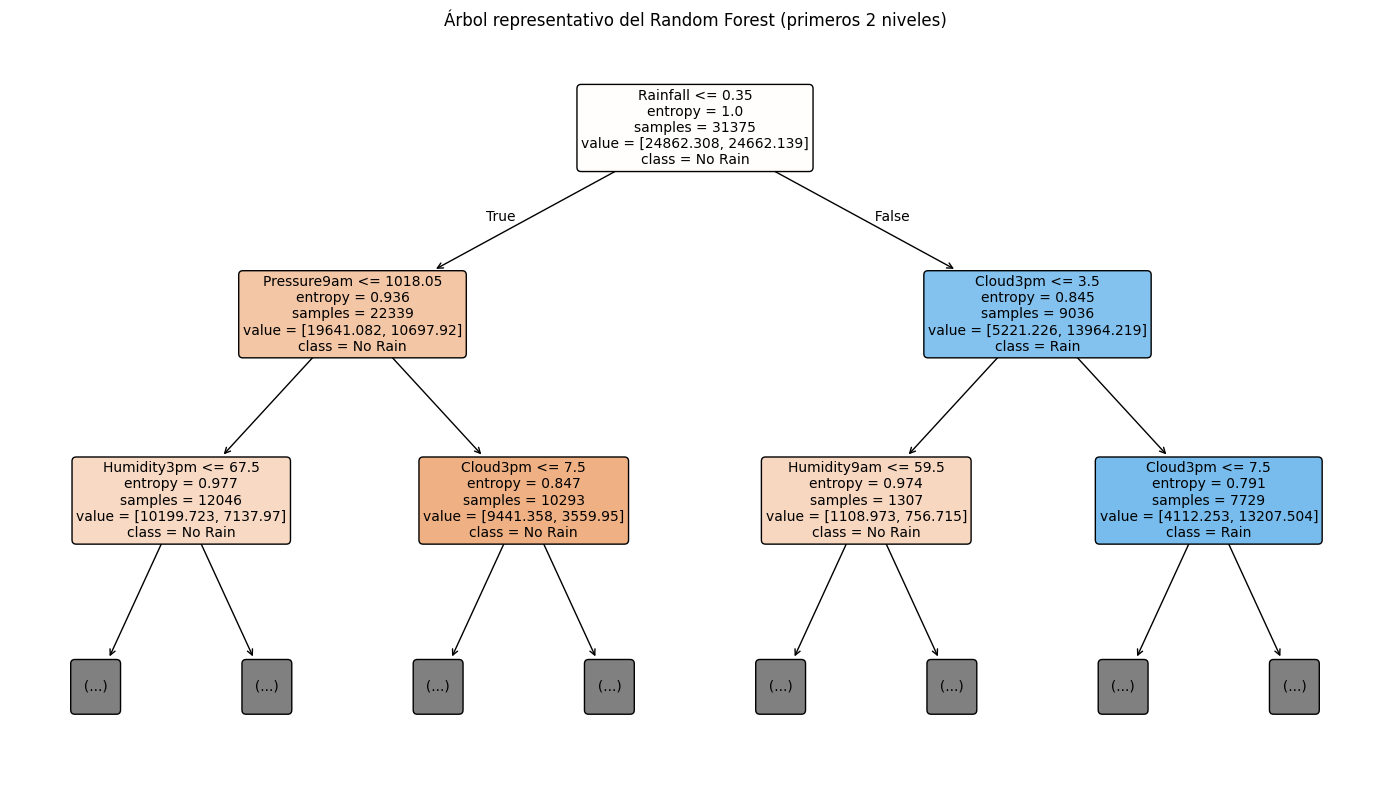

In [ ]:
arbol_rep = rf_final.estimators_[0]

plt.figure(figsize=(14, 8))
tree.plot_tree(
    arbol_rep,
    max_depth     = 2,
    feature_names = X.columns.tolist(),
    filled        = True,
    rounded       = True,
    class_names   = ['No Rain', 'Rain'],
    fontsize      = 10
)
plt.title('Árbol representativo del Random Forest (primeros 2 niveles)')
plt.tight_layout()
plt.show()

#### Interpretación del árbol representativo del Random Forest
A diferencia del árbol de decisión individual donde el nodo raíz era `Humidity3pm`, este árbol del bosque divide primero por `Rainfall <= 0.35`, lo cual refleja que al considerar solo un subconjunto aleatorio de features en cada split, cada árbol puede encontrar variables distintas como punto de partida.

**Rama izquierda (Rainfall ≤ 0.35 → lluvia escasa, tiende a No Rain):**
Con 22.339 muestras, el nodo evalúa `Pressure9am <= 1018.05`. Una presión baja en la mañana es indicador meteorológico clásico de inestabilidad atmosférica. Si la presión es baja Y la humedad a las 3pm es alta (> 67.5), aumenta la probabilidad de lluvia. Si la presión es baja pero la caída de humedad es pequeña (`HumidityDrop <= 6.5`), el modelo tiende a predecir No Rain igualmente.

**Rama derecha (Rainfall > 0.35 → ya llovió algo, tiende a Rain):**
Con solo 9.036 muestras pero mayoría clase Rain, subdivide por `Cloud9am <= 4.25`. Si hay poca nubosidad matutina a pesar de la lluvia, evalúa `MaxTemp <= 25.85`. Si hay mucha nube y además `Humidity9am > 78.5`, el modelo predice lluvia con bastante confianza.

La diferencia clave con el árbol del Modelo 1 es que aquí no aparece `Humidity3pm` como nodo raíz, aunque sí aparece en niveles inferiores. Esto ilustra el mecanismo central del Random Forest: al forzar subconjuntos aleatorios de variables, los árboles se decorrelacionan entre sí, lo que reduce la varianza del ensamble.

### Modelo 3 – XGBoost

Como tercer modelo se elige XGBoost (Extreme Gradient Boosting), una implementación optimizada del algoritmo de Gradient Boosting que construye árboles de decisión de forma secuencial, donde cada árbol nuevo se entrena para corregir los errores del anterior minimizando una función de pérdida mediante descenso por gradiente.

XGBoost construye árboles en secuencia priorizando los ejemplos mal clasificados, lo que en la práctica genera un mejor trade-off sesgo-varianza y suele traducirse en mayor precisión predictiva.
Por otro lado, los tres modelos representan familias distintas (árbol individual → bagging → boosting), lo que permitirá una comparación significativa en el cuadro final.

Además, XGBoost reduce el riesgo de overfitting respecto al Gradient Boosting clásico, y es naturalmente robusto frente a outliers sin requerir que las features estén normalizadas.

Por último, XGBoost ofrece el parámetro scale_pos_weight, que permite compensar explícitamente el desbalance de clases penalizando más los errores sobre la clase minoritaria durante el entrenamiento. Esto es especialmente relevante en este problema donde solo el 22% de los registros corresponden a días de lluvia, y donde el recall es la métrica prioritaria de evaluación.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Modelo inicial
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_inicial = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_inicial.fit(X_train, y_train)
y_pred_xgb = xgb_inicial.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8589041095890411
Recall: 0.545686203130688
Precision: 0.7487512487512488
F1 Score: 0.63129079806275
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      9663
           1       0.75      0.55      0.63      2747

    accuracy                           0.86     12410
   macro avg       0.81      0.75      0.77     12410
weighted avg       0.85      0.86      0.85     12410



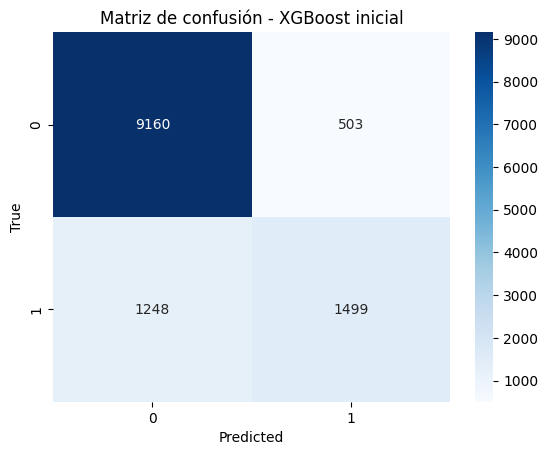

In [ ]:
# Matriz de confusión inicial
tabla_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(tabla_xgb, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de confusión - XGBoost inicial')
plt.show()

#### Optimización de hiperparámetros

In [ ]:
param_grid_xgb = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=neg/pos,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),
    param_grid_xgb,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_xgb.best_params_)
print("Mejor F1 en CV:", grid_xgb.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Mejor F1 en CV: 0.6495421445141557


In [ ]:
xgb_final = grid_xgb.best_estimator_
y_pred_xgb_final = xgb_final.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_final))
print("Recall:", recall_score(y_test, y_pred_xgb_final))
print("Precision:", precision_score(y_test, y_pred_xgb_final))
print("F1 Score:", f1_score(y_test, y_pred_xgb_final))
print(classification_report(y_test, y_pred_xgb_final))

# Evaluación en el conjunto de entrenamiento (para detectar overfitting)
y_train_pred_xgb = xgb_final.predict(X_train)
print("=== XGBoost — Performance en TRAIN ===")
print("Train — Accuracy: ", accuracy_score(y_train, y_train_pred_xgb))
print("Train — Recall:   ", recall_score(y_train, y_train_pred_xgb))
print("Train — Precision:", precision_score(y_train, y_train_pred_xgb))
print("Train — F1:       ", f1_score(y_train, y_train_pred_xgb))

Accuracy: 0.8190169218372281
Recall: 0.748452857662905
Precision: 0.5693713652727777
F1 Score: 0.6467442592010066
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      9663
           1       0.57      0.75      0.65      2747

    accuracy                           0.82     12410
   macro avg       0.75      0.79      0.76     12410
weighted avg       0.84      0.82      0.83     12410

=== XGBoost — Performance en TRAIN ===
Train — Accuracy:  0.8463413651382061
Train — Recall:    0.8338946027122963
Train — Precision: 0.6122694466720129
Train — F1:        0.7060999576124234


El modelo inicial se entrena sin corrección de desbalance para observar el comportamiento base del algoritmo. Como era de esperarse, el modelo obtiene un recall de 0.55 para la clase minoritaria (lluvia), evidenciando que tiende a predecir mayormente "No llueve" para maximizar el accuracy, ignorando una proporción significativa de los días de lluvia real.
Por este motivo, se incorpora scale_pos_weight=neg/pos como hiperparámetro clave en la optimización de XgBoost. Este parámetro calcula la proporción entre ejemplos negativos y positivos (≈ 3.5), indicándole al modelo que cada error sobre la clase minoritaria debe penalizarse 3.5 veces más que un error sobre la clase mayoritaria. Es el equivalente directo de class_weight='balanced' utilizado en árboles de decisión y Random Forest.

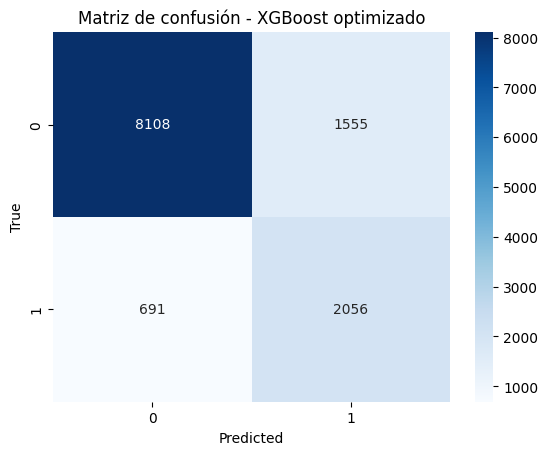

In [ ]:
# Matriz de confusión final
tabla_xgb_final = confusion_matrix(y_test, y_pred_xgb_final)
sns.heatmap(tabla_xgb_final, cmap='Blues', annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de confusión - XGBoost optimizado')
plt.show()

#### Importancia de atributos

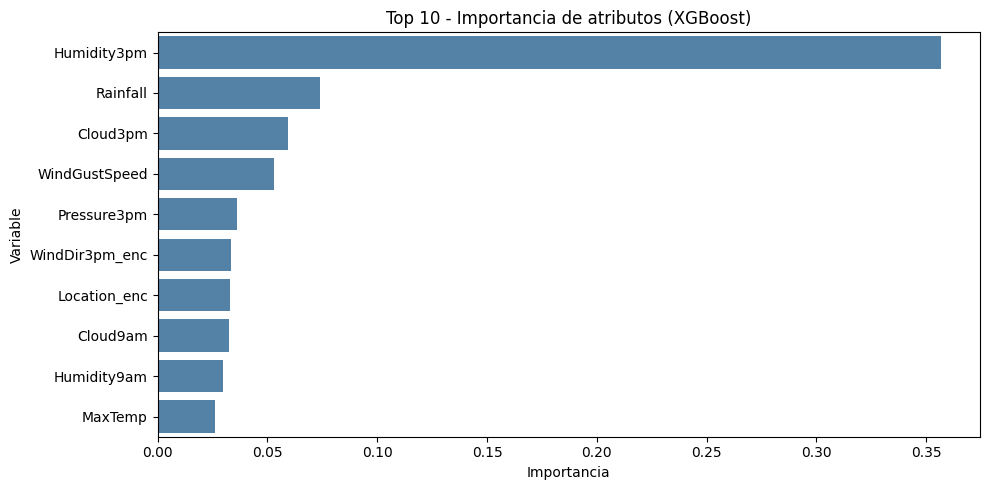

Humidity3pm      0.36
Rainfall         0.07
Cloud3pm         0.06
WindGustSpeed    0.05
Pressure3pm      0.04
WindDir3pm_enc   0.03
Location_enc     0.03
Cloud9am         0.03
Humidity9am      0.03
MaxTemp          0.03
dtype: float32


In [ ]:
importancias_xgb = pd.Series(
    xgb_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importancias_xgb.values, y=importancias_xgb.index, color='steelblue')
plt.title('Top 10 - Importancia de atributos (XGBoost)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print(importancias_xgb)

## 3. Comparación de modelos

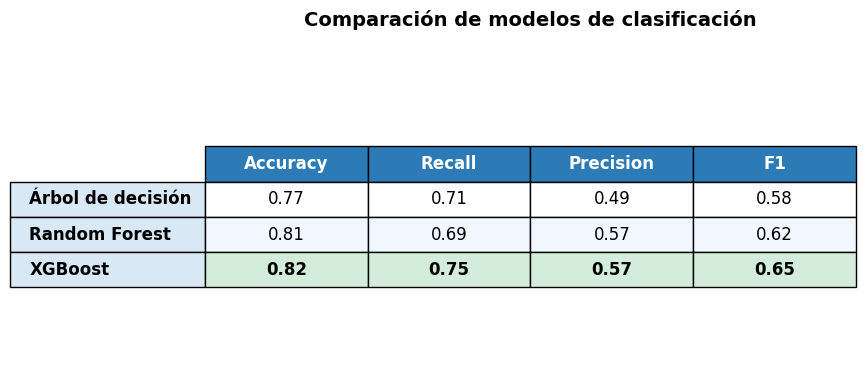

In [ ]:
# Cuadro comparativo de modelos
modelos = ['Árbol de decisión', 'Random Forest', 'XGBoost']
metricas = {
    'Accuracy':  [accuracy_score(y_test, y_pred_final),
                  accuracy_score(y_test, y_pred_rf_final),
                  accuracy_score(y_test, y_pred_xgb_final)],
    'Recall':    [recall_score(y_test, y_pred_final),
                  recall_score(y_test, y_pred_rf_final),
                  recall_score(y_test, y_pred_xgb_final)],
    'Precision': [precision_score(y_test, y_pred_final),
                  precision_score(y_test, y_pred_rf_final),
                  precision_score(y_test, y_pred_xgb_final)],
    'F1':        [f1_score(y_test, y_pred_final),
                  f1_score(y_test, y_pred_rf_final),
                  f1_score(y_test, y_pred_xgb_final)],
}

df_comp = pd.DataFrame(metricas, index=modelos)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

tabla = ax.table(
    cellText=df_comp.values.round(2),
    rowLabels=df_comp.index,
    colLabels=df_comp.columns,
    cellLoc='center',
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1.4, 2)

# Colores de encabezado y filas
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c7bb6')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_facecolor('#d9e8f5')
        cell.set_text_props(fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f7ff')
    else:
        cell.set_facecolor('white')

# Resaltar mejor valor por columna
for col_idx, col_name in enumerate(df_comp.columns):
    mejor_fila = df_comp[col_name].idxmax()
    mejor_row = df_comp.index.get_loc(mejor_fila) + 1
    tabla[mejor_row, col_idx].set_facecolor('#d4edda')
    tabla[mejor_row, col_idx].set_text_props(fontweight='bold')

plt.title('Comparación de modelos de clasificación', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Se elige XGBoost como modelo final. Es el que mejor desempeño obtiene en las métricas prioritarias para este problema: mayor recall (0.75) y mayor F1 (0.65), manteniendo una accuracy y precisión similares al Random Forest.
Dado el desbalance de clases presente en el dataset (78% No lluvia / 22% lluvia) y el contexto meteorológico, el recall es la métrica más relevante: es más costoso no detectar un día de lluvia real que generar una falsa alarma. XGBoost logra detectar correctamente 3 de cada 4 días de lluvia real, superando al árbol de decisión (0.71) y al Random Forest (0.69), siendo por tanto el modelo más adecuado para este problema.

## Guardado de modelos y dataset procesado

In [ ]:
import joblib
import os

# Scaler (necesario para reproducir predicciones con Modelo 3)
joblib.dump(scaler, "TA047R_TP1_GRUPO02_EJ2_scaler.pkl")

# Modelo 1 — Árbol de decisión (optimizado con GridSearchCV)
joblib.dump(model_final, "TA047R_TP1_GRUPO02_EJ2_modelo_arbol_decision.pkl")

# Modelo 2 — Random Forest (optimizado con RandomizedSearchCV)
joblib.dump(rf_final, "TA047R_TP1_GRUPO02_EJ2_modelo_random_forest.pkl")

# Modelo 3 — XGBoost (optimizado con GridSearchCV)
joblib.dump(xgb_final, "TA047R_TP1_GRUPO02_EJ2_modelo_xgboost.pkl")

# Verificación
archivos = [
    "TA047R_TP1_GRUPO02_EJ2_scaler.pkl",
    "TA047R_TP1_GRUPO02_EJ2_modelo_arbol_decision.pkl",
    "TA047R_TP1_GRUPO02_EJ2_modelo_random_forest.pkl",
    "TA047R_TP1_GRUPO02_EJ2_modelo_xgboost.pkl",
]
print("Archivos guardados:")
for f in archivos:
    size = os.path.getsize(f) / 1024
    print(f"  {f}  →  {size:.1f} KB")

nombre_dataset = "TA047R_TP1_GRUPO02_EJ2_weather_australia_procesado.csv"
df.to_csv(nombre_dataset, index=False)

size_kb = os.path.getsize(nombre_dataset) / 1024
print(f"Dataset guardado: {nombre_dataset}")
print(f"Tamaño: {size_kb:.1f} KB")
print(f"Shape: {df.shape}")

Archivos guardados:
  TA047R_TP1_GRUPO02_EJ2_scaler.pkl  →  1.4 KB
  TA047R_TP1_GRUPO02_EJ2_modelo_arbol_decision.pkl  →  82.2 KB
  TA047R_TP1_GRUPO02_EJ2_modelo_random_forest.pkl  →  8937.6 KB
  TA047R_TP1_GRUPO02_EJ2_modelo_xgboost.pkl  →  498.2 KB
Dataset guardado: TA047R_TP1_GRUPO02_EJ2_weather_australia_procesado.csv
Tamaño: 10066.7 KB
Shape: (62046, 33)
